# Haberman Survival Data Set Exploratory Data Analysis

* Sources: (a) Donor: Tjen-Sien Lim (limt@stat.wisc.edu) (b) Date: March 4, 1999

* Relevant Information: The dataset contains cases from a study that was conducted between 1958 and 1970 at the University of Chicago's Billings Hospital on the survival of patients who had undergone surgery for breast cancer.

*  Objective : Classify the survival status of person as belonging to the one of the three classes with the help of 3 Feature
*  i.e Age of patient at time of operation ,Patient's year of operation ,Number of positive axillary nodes detected 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load haberman data set into pandas data Frame
haberman = pd.read_csv('haberman.csv')

In [3]:
# Data points and feature that haberman survival data set have 
print(haberman.shape)

(306, 4)


In [4]:
# Name of the columns and variables that haberman survival data set have
print(haberman.columns)

Index(['age', 'year', 'nodes', 'status'], dtype='object')


In [5]:
# Points Belonging to the each Classes  
print(haberman['status'].value_counts())

1    225
2     81
Name: status, dtype: int64


### Haberman Data Set is an Imbalance data set as

* 225 person belongs to the status 1
* 81  person belongs to the status 2 

# 2D Scatter plot

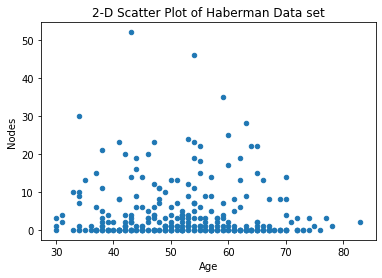

In [6]:
## scatter plot scatter all points which haberman data set have according to variables or features

haberman.plot(kind='scatter',x='age',y='nodes')
plt.xlabel('Age')
plt.ylabel('Nodes')
plt.title('2-D Scatter Plot of Haberman Data set')
plt.show()


### Observation from 2D scatter Plot

* Age of the person in haberman data set vary from around 30 to 84 approx
* Number of positive auxilory nodes Detected vary from arounf 0 to 52 approx
* Cannot able to determine what classes these points Belong to.

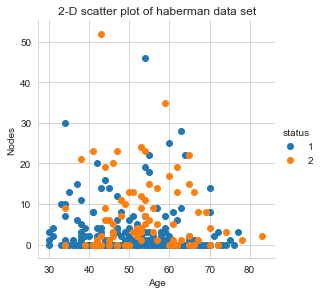

In [7]:
sns.set_style('whitegrid')
sns.FacetGrid(haberman,hue='status',height=4).map(plt.scatter,'age','nodes').add_legend()
plt.xlabel('Age')
plt.ylabel('Nodes')
plt.title('2-D scatter plot of haberman data set')
plt.show()

### Conclusion from 2D scatter plot

* As from legend we can observe that Blue color circle belongs to status1 and Orange color circle belongs to Status2
* From the Graph it is very Difficult to classify the Two status using 2 D scatter Plot as they overlap Each other

# Pair Plot

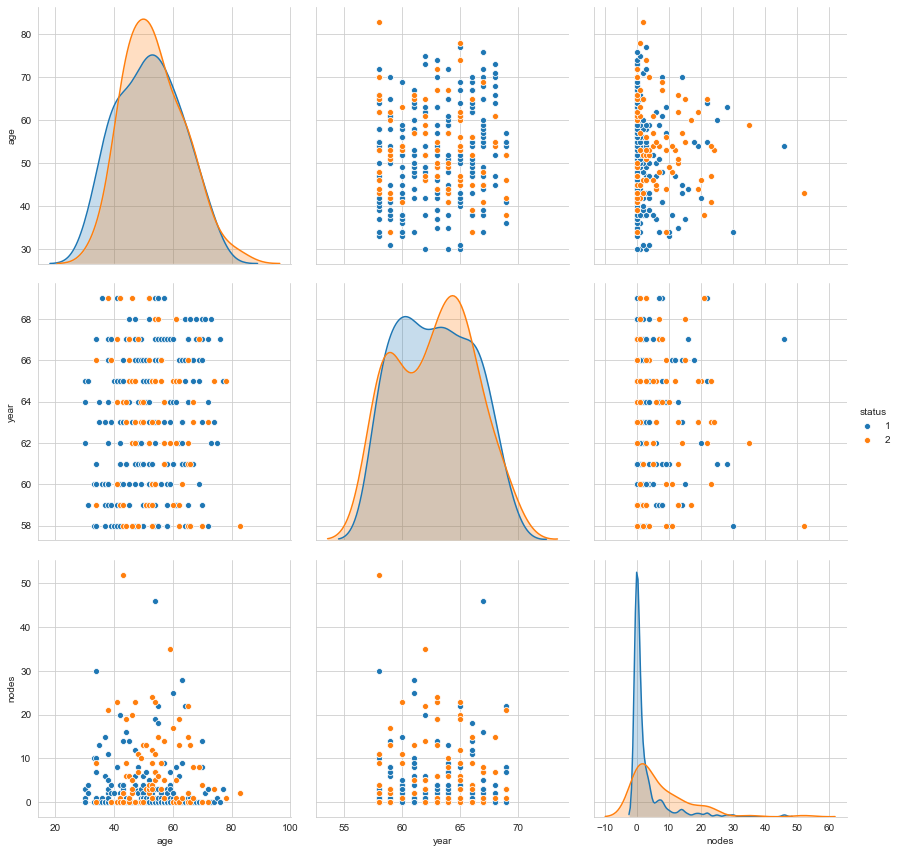

In [8]:
sns.set_style('whitegrid')
sns.pairplot(haberman,hue='status',height=4,vars=['age','year','nodes'])
plt.show()

### Observation From the pair plot

* From the pair plot it very difficult to seperate status 1 and status 2 
* From all the graph it is observed year and node graph little seperable as compared to other graph

# 1-D Scatter Plot using one feature

In [9]:
haberman_1 = haberman[haberman['status'] == 1]
haberman_2 = haberman[haberman['status'] == 2]

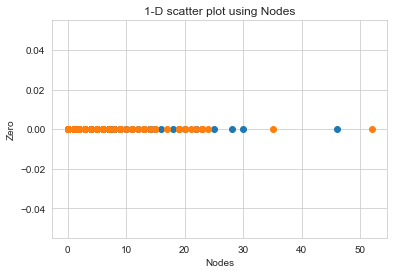

In [10]:
plt.plot(haberman_1['nodes'],np.zeros_like(haberman_1['nodes']),'o')
plt.plot(haberman_2['nodes'],np.zeros_like(haberman_2['nodes']),'o')
plt.xlabel('Nodes')
plt.ylabel('Zero')
plt.title('1-D scatter plot using Nodes')
plt.show()

### Conclusion from 1- D scatter plot

* it is very diffcult to seperate the blue circle and green circle
* we don't know number of points between 0 to 20 

## Code to Plot a Histogram 



#### Histogram using Number of positive axillary nodes detected

[]

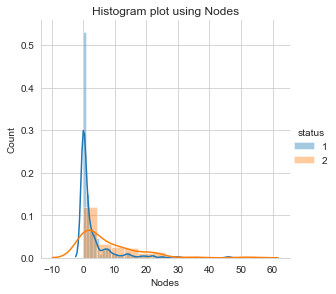

In [11]:
sns.set_style('whitegrid')
sns.FacetGrid(haberman,hue='status',height=4).map(sns.distplot,'nodes').add_legend()
plt.xlabel('Nodes')
plt.ylabel('Count')
plt.title('Histogram plot using Nodes')
plt.plot()

#### Histogram using Patient's year of operation (year - 1900, numerical)

[]

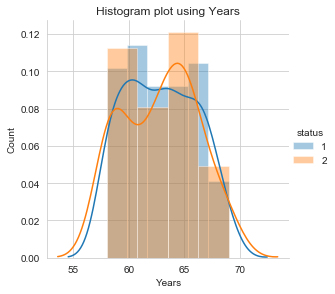

In [12]:
sns.set_style('whitegrid')
sns.FacetGrid(haberman,hue='status',height=4).map(sns.distplot,'year').add_legend()
plt.xlabel('Years')
plt.ylabel('Count')
plt.title('Histogram plot using Years')
plt.plot()

#### Histogram using Age of patient at time of operation 

[]

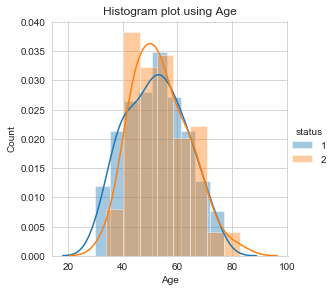

In [13]:
sns.set_style('whitegrid')
sns.FacetGrid(haberman,hue='status',height=4).map(sns.distplot,'age').add_legend()
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Histogram plot using Age')
plt.plot()

### Concusion From Histogram

* As from the Histogram Plot we observed that status1 and status2 are overlapping Each other
* From the plot we observed that distribution using Nodes are less overlapping than age and years

# CDF And PDF Analysis



[0.18164251 0.0173913  0.00483092 0.0057971  0.00386473 0.00096618
 0.00193237 0.         0.         0.00096618]
[ 0.   4.6  9.2 13.8 18.4 23.  27.6 32.2 36.8 41.4 46. ]
[0.83555556 0.08       0.02222222 0.02666667 0.01777778 0.00444444
 0.00888889 0.         0.         0.00444444]


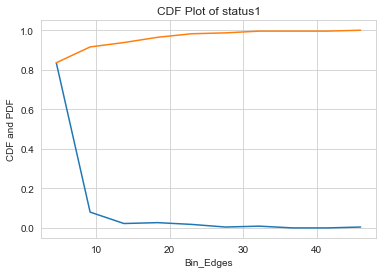

In [14]:
counts,bin_edges  = np.histogram(haberman_1['nodes'],bins=10,density=True)
print(counts)
print(bin_edges)
pdf = counts/sum(counts)
print(pdf)
cdf = np.cumsum(pdf)

plt.plot(bin_edges[1:],pdf)
plt.plot(bin_edges[1:],cdf)
plt.xlabel('Bin_Edges')
plt.ylabel('CDF and PDF')
plt.title("CDF Plot of status1")
plt.show()

### Conclusion From PDF using Nodes

* About 97 Percent of Survival Status1 Having less than 20 Number of positive axillary nodes detected  

[0.18164251 0.0173913  0.00483092 0.0057971  0.00386473 0.00096618
 0.00193237 0.         0.         0.00096618]
[ 0.   4.6  9.2 13.8 18.4 23.  27.6 32.2 36.8 41.4 46. ]
[0.83555556 0.08       0.02222222 0.02666667 0.01777778 0.00444444
 0.00888889 0.         0.         0.00444444]
[0.10921178 0.02849003 0.02611586 0.00949668 0.01424501 0.
 0.00237417 0.         0.         0.00237417]
[ 0.   5.2 10.4 15.6 20.8 26.  31.2 36.4 41.6 46.8 52. ]
[0.56790123 0.14814815 0.13580247 0.04938272 0.07407407 0.
 0.01234568 0.         0.         0.01234568]


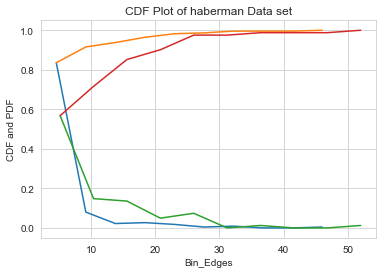

In [15]:
## Plots of CDF of Nodes for different Surviaval status

# Status1

counts,bin_edges  = np.histogram(haberman_1['nodes'],bins=10,density=True)
print(counts)
print(bin_edges)
pdf = counts/sum(counts)
print(pdf)
cdf = np.cumsum(pdf)

plt.plot(bin_edges[1:],pdf)
plt.plot(bin_edges[1:],cdf)

# Status 2
counts,bin_edges  = np.histogram(haberman_2['nodes'],bins=10,density=True)
print(counts)
print(bin_edges)
pdf = counts/sum(counts)
print(pdf)
cdf = np.cumsum(pdf)

plt.plot(bin_edges[1:],pdf)
plt.plot(bin_edges[1:],cdf)
plt.xlabel('Bin_Edges')
plt.ylabel('CDF and PDF')
plt.title("CDF Plot of haberman Data set")

plt.show()

## Conclusion From CDF 

* Person Having Number of positive axillary nodes detected less 10 Having approx 20% greater chance of Survial Status1
* Person Having Number of positive axillary nodes detected less 20 Having approx 5%  greater chance of Survial Status1
* Person Having Number of positive axillary nodes detected less 25 Having approx 1%  greater chance of Survial Status1

# BOX Plot

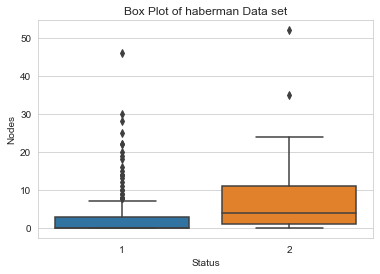

In [16]:
sns.boxplot(x='status',y='nodes',data=haberman)
plt.xlabel('Status')
plt.ylabel('Nodes')
plt.title("Box Plot of haberman Data set")
plt.show()

## Conclusion from the box plots 

* Approx 50% of status 1 having nodes less than 2 But 30% of status 2 having nodes less than 2 
* i.e if node<2 lies in status1 having Error Rate of 30% 
* Most of status 1 as well as status2 lies in between node 1 to 3
* Approx 50% of status 2 lies in between 1 to 11 nodes

# Violin Plot

## Combination of Both Violin as well as Histogram Plot

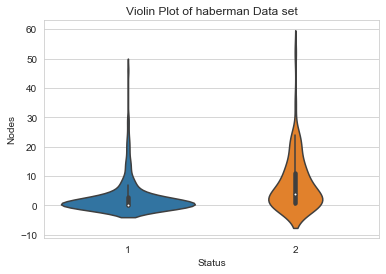

In [17]:
sns.violinplot(x='status',y='nodes',data=haberman)
plt.xlabel('Status')
plt.ylabel('Nodes')
plt.title("Violin Plot of haberman Data set")
plt.show()

## Conclusion



* As Exploratary Data Analysis of haberman Data set it is Much harder to Seperate between Status 1 and Status 2 with 3 Feature 
* as they overlap each other
* ie Age of patient at time of operation,Patient's year of operation,Number of positive axillary nodes detected
* From the  Histogram plot we observed that distribution using Nodes are less overlapping than age and year
